In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor
import shap
import os
import fiona
from geopy.distance import geodesic

In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [4]:
caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y

In [5]:
compagnies = compagnies.to_crs(epsg=4326)
print(compagnies.geometry.head())

0    POLYGON ((5.98589 47.33082, 5.98621 47.33091, ...
1    POLYGON ((6.37208 47.28665, 6.37036 47.28572, ...
2    POLYGON ((6.17776 47.01394, 6.17858 47.01315, ...
3    POLYGON ((6.29216 46.85959, 6.29174 46.85793, ...
4    MULTIPOLYGON (((6.35375 46.71830, 6.35262 46.7...
Name: geometry, dtype: geometry


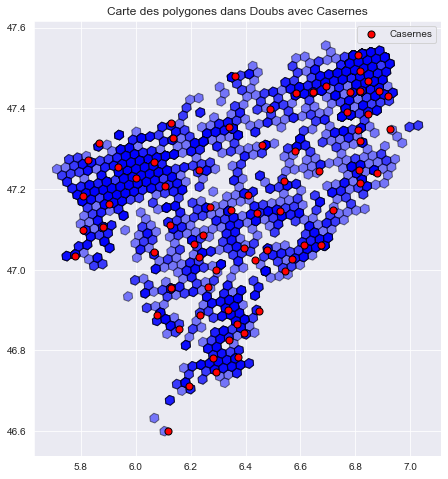

In [6]:
fig, ax = plt.subplots(figsize=(8,8))
doubs_data.plot(ax=ax, color="blue", edgecolor="black", alpha=0.5, label="Polygones (Doubs)")
caserne.plot(ax=ax, color="red", markersize=50, edgecolor="black", label="Casernes")
ax.set_title("Carte des polygones dans Doubs avec Casernes")
ax.legend()
plt.show()

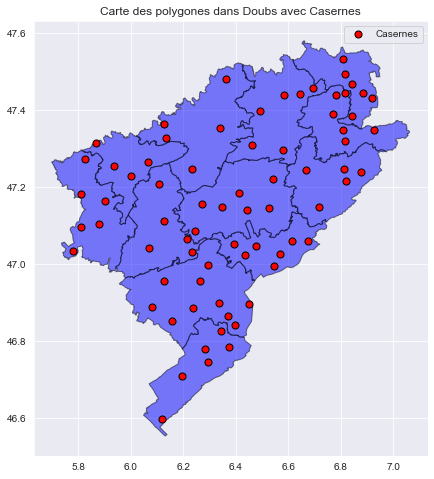

In [7]:
fig, ax = plt.subplots(figsize=(8,8))
compagnies.plot(ax=ax, color="blue", edgecolor="black", alpha=0.5, label="Polygones (Doubs)")
caserne.plot(ax=ax, color="red", markersize=50, edgecolor="black", label="Casernes")
ax.set_title("Carte des polygones dans Doubs avec Casernes")
ax.legend()
plt.show()

In [8]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

In [9]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

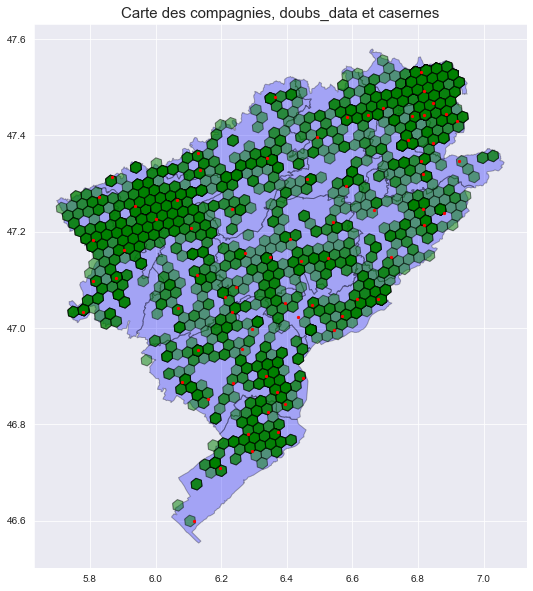

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))

compagnies.plot(ax=ax, color='blue', alpha=0.3, edgecolor='black')

doubs_data.plot(ax=ax, color='green', alpha=0.5, edgecolor='black')

caserne.plot(ax=ax, color='red', marker='o', markersize=5)

ax.set_title("Carte des compagnies, doubs_data et casernes", fontsize=15)

plt.show()

In [11]:
doubs_data['id_compagnie'] = None

for idx, hexagone in doubs_data.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if len(intersecting_companies) == 1:
        doubs_data.at[idx, 'id_compagnie'] = intersecting_companies.iloc[0]['id']
    elif len(intersecting_companies) > 1:
        max_area = 0
        best_company_id = None
        for _, company in intersecting_companies.iterrows():
            intersection = hexagone['geometry'].intersection(company['geometry'])
            area = intersection.area
            if area > max_area:
                max_area = area
                best_company_id = company['id']

        doubs_data.at[idx, 'id_compagnie'] = best_company_id

doubs_data.head()

,hex_id,raison_sortie,date_debut,date_fin,label,year,date,departement,duree_minutes,geometry,duree,centroid,centroid_lon,centroid_lat,id_compagnie
0,871f820aaffffff,NATURELS,2014-10-02 14:08:53,2014-10-02 19:54:25,1.0,2014.0,2014-10-02,departement-25-doubs,345.533333,"POLYGON ((6.21735 46.89696, 6.21925 46.88490, ...",0 days 05:45:32,POINT (6.23394 46.89289),6.233937,46.892889,4.0
1,871f82d61ffffff,NATURELS,2014-10-03 19:33:59,2014-10-03 19:55:31,1.0,2014.0,2014-10-03,departement-25-doubs,21.533333,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",0 days 00:21:32,POINT (5.80760 47.26166),5.807597,47.261659,12.0
2,871f82d61ffffff,NATURELS,2014-10-04 19:24:49,2014-10-04 19:59:02,1.0,2014.0,2014-10-04,departement-25-doubs,34.216667,"POLYGON ((5.79096 47.26562, 5.79292 47.25365, ...",0 days 00:34:13,POINT (5.80760 47.26166),5.807597,47.261659,12.0
3,871f82d4dffffff,NATURELS,2014-10-04 20:10:43,2014-10-04 20:42:34,1.0,2014.0,2014-10-04,departement-25-doubs,31.850000,"POLYGON ((5.87805 47.22180, 5.88000 47.20981, ...",0 days 00:31:51,POINT (5.89468 47.21782),5.894684,47.217820,1.0
4,871f82700ffffff,NATURELS,2014-10-05 12:57:52,2014-10-05 13:24:24,1.0,2014.0,2014-10-05,departement-25-doubs,26.533333,"POLYGON ((6.30249 46.75999, 6.30437 46.74791, ...",0 days 00:26:32,POINT (6.31905 46.75590),6.319047,46.755896,5.0


In [12]:
caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnie'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnie'].isna().sum()
print(f"Nombre de casernes sans id_compagnie : {none_count}")

print(caserne[['compagnie', 'id_compagnie']].head())

if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

print(caserne.head())

Nombre de casernes sans id_compagnie : 0
         compagnie  id_compagnie
0         Besançon           1.0
1  Baume-les-Dames           2.0
2      Montbéliard           6.0
3       Pontarlier           4.0
4      Montbéliard           6.0
    id_pg                    sous_type cs_cod               nom_x  \
0  840642  Centre de Secours Principal  25155        BESANCON EST   
1  840674            Centre de Secours  25706     PREMIER PLATEAU   
2  840713                          CPI  25703  PLATEAU DE BLAMONT   
3  840644  Centre de Secours Principal  25462          PONTARLIER   
4  840712                          CPI  25004         ABBEVILLERS   

         compagnie                  geometry       lon        lat  \
0         Besançon  POINT (6.06536 47.26571)  6.065359  47.265714   
1  Baume-les-Dames  POINT (6.23181 47.24656)  6.231807  47.246561   
2      Montbéliard  POINT (6.84404 47.38538)  6.844042  47.385383   
3       Pontarlier  POINT (6.33503 46.89990)  6.335031  46.899903   
4

In [13]:
doubs_data = doubs_data.merge(firepoint, on='hex_id', how='left')

doubs_data = doubs_data.merge(caserne[['id_compagnie', 'lon', 'lat']],
                              on='id_compagnie', how='left', suffixes=('', '_caserne'))

threshold = 0.7 * len(doubs_data)
doubs_data.dropna(axis=1, thresh=threshold, inplace=True)

doubs_data.dropna(inplace=True)

In [14]:
def calculate_distance(row):
    return geodesic((row['centroid_lat'], row['centroid_lon']), (row['lat'], row['lon'])).km

doubs_data['distance_caserne'] = doubs_data.apply(calculate_distance, axis=1)

doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'])
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['day_of_week'] = doubs_data['date_debut'].dt.dayofweek
doubs_data['month'] = doubs_data['date_debut'].dt.month

doubs_data = pd.get_dummies(doubs_data, columns=['raison_sortie', 'departement', 'label', 'id_compagnie'], drop_first=True)

doubs_data['vegetation_index'] = doubs_data[['NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI']].mean(axis=1)

doubs_data['road_accessibility'] = doubs_data[['motorway', 'primary', 'secondary', 'tertiary', 'path']].sum(axis=1)

In [15]:
doubs_data.columns

Index(['hex_id', 'date_debut', 'date_fin', 'year', 'date', 'duree_minutes',
       'geometry', 'duree', 'centroid', 'centroid_lon', 'centroid_lat',
       'scale0', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
       'motorway', 'primary', 'secondary', 'tertiary', 'path', 'population',
       'elevation', 'foret_encoder', 'highway_encoder', 'PasDeforet',
       'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus',
       'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre',
       'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'sinister', 'lon',
       'lat', 'distance_caserne', 'hour', 'day_of_week', 'month',
       'id_compagnie_2.0', 'id_compagnie_3.0', 'id_compagnie_4.0',
       'id_compagnie_5.0', 'id_compagnie_6.0', 'id_compagnie_7.0',
       'id_compagnie_8.0', 'id_compagnie_9.0', 'id_compagnie_1

In [17]:
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'])
doubs_data['date_fin'] = pd.to_datetime(doubs_data['date_fin'])

doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['weekday'] = doubs_data['date_debut'].dt.weekday
doubs_data['month'] = doubs_data['date_debut'].dt.month
doubs_data['year'] = doubs_data['date_debut'].dt.year

def haversine_distance(lon1, lat1, lon2, lat2):
    return geodesic((lat1, lon1), (lat2, lon2)).km

doubs_data['distance_caserne'] = doubs_data.apply(
    lambda row: haversine_distance(row['centroid_lon'], row['centroid_lat'],
                                   row['lon'], row['lat']), axis=1)

doubs_features = doubs_data[['hex_id', 'duree_minutes', 'hour', 'weekday', 'month', 'year',
                             'scale0', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute',
                             'motorway', 'primary', 'secondary', 'tertiary', 'path',
                             'population', 'elevation', 'foret_encoder', 'highway_encoder',
                             'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères',
                             'Douglas', 'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR',
                             'Peuplier', 'Pin autre', 'Pin laricio, pin noir', 'Pin maritime',
                             'Pin sylvestre', 'Pins mélangés', 'Robinier', 'Sapin, épicéa',
                             'water', 'tree', 'grass', 'crops', 'shrub', 'flooded', 'built',
                             'bare', 'snow', 'sinister', 'distance_caserne']]

In [26]:
X = doubs_features.drop(columns=['duree_minutes'])
y = doubs_features['duree_minutes']

hex_counts = doubs_features['hex_id'].value_counts()
hex_ids = hex_counts.index.tolist()

np.random.seed(42)
np.random.shuffle(hex_ids)

train_hex_ids, test_hex_ids = [], []
train_size, test_size = 0, 0
total_size = len(doubs_features)

for hex_id in hex_ids:
    if train_size / total_size < 0.8:
        train_hex_ids.append(hex_id)
        train_size += hex_counts[hex_id]
    else:
        test_hex_ids.append(hex_id)
        test_size += hex_counts[hex_id]

X_train = X[X['hex_id'].isin(train_hex_ids)].drop(columns=['hex_id'])
y_train = y[X['hex_id'].isin(train_hex_ids)]

X_test = X[X['hex_id'].isin(test_hex_ids)].drop(columns=['hex_id'])
y_test = y[X['hex_id'].isin(test_hex_ids)]

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")


MAE: 48.93
RMSE: 125.29
R²: -0.4004
